<a href="https://colab.research.google.com/github/sudo-ansh007/forecast/blob/main/win_probability_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score)


In [ ]:
train = pd.read_csv("ml_train.csv").sort_values("created_date").reset_index(drop=True)
train.head()


,display_id,acv,created_date,evidence,days_in_current_stage,days_in_sales_cycle,stall_ratio,contract_months,num_stakeholders,has_champion,poc,opportunity_type,source,geo,segment,is_won
0,OPP-102,8883.0,2023-01-12 00:00:00.000,2,13.0,78.5,0.165605,12.0,0,0,0,new,outbound,amer,start-up,1
1,OPP-246,20964.0,2023-02-20 00:00:00.000,3,13.0,78.5,0.165605,12.0,1,1,0,new,events,apj,mid-market,1
2,OPP-225,8675.0,2023-04-01 00:00:00.000,3,13.0,78.5,0.165605,12.0,1,1,0,new,outbound,apj,mid-market,1
3,OPP-216,21687.0,2023-04-01 00:00:00.000,4,13.0,78.5,0.165605,12.0,2,1,0,new,events,apj,mid-market,1
4,OPP-234,3614.0,2023-04-01 00:00:00.000,2,13.0,78.5,0.165605,12.0,0,0,0,new,events,apj,mid-market,1


In [39]:
FEATURES = ["days_in_current_stage", "days_in_sales_cycle", "stall_ratio", "contract_months", "num_stakeholders", "has_champion", "poc", "opportunity_type", "source", "geo", "segment"]
CATEGORICALS = ["opportunity_type", "source", "geo", "segment"]

print(len(train), "deals", train.is_won.sum(), "won")


3573 deals 541 won


In [40]:
num = [f for f in FEATURES if f not in CATEGORICALS]
X = train[num].astype(float)
for c in CATEGORICALS:
    X = pd.concat([X, pd.get_dummies(train[c], prefix=c, dtype=float)], axis=1)

# segment-specific patterns: let each segment learn its own slope on the features
# that matter most (from the permutation-importance run below), instead of one
# shared slope across enterprise/mid-market/smb/start-up.
INTERACT_WITH = ["days_in_current_stage", "stall_ratio", "contract_months"]
seg_dum = pd.get_dummies(train.segment, prefix="seg_x", dtype=float)
for s in seg_dum.columns:
    for f in INTERACT_WITH:
        X[f"{s}__{f}"] = seg_dum[s] * train[f]

y = train.is_won.to_numpy()

cut = int(len(train) * 0.8)
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print(f"train {len(y_train)}/{y_train.sum()} won   test {len(y_test)}/{y_test.sum()} won")


train 2858/462 won   test 715/79 won


In [41]:
model = CalibratedClassifierCV(XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05, min_child_weight=1, random_state=0, eval_metric="logloss"), method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)).fit(X_train, y_train)

p_train = model.predict_proba(X_train)[:,1]
p_test = model.predict_proba(X_test)[:,1]


In [42]:
def m(yy, pp):
    return {"n": len(yy), "wins": yy.sum(), "base": yy.mean(), "PR_AUC": average_precision_score(yy, pp), "lift": average_precision_score(yy, pp) / yy.mean(), "ROC": roc_auc_score(yy, pp), "Brier": brier_score_loss(yy, pp), "sum_p/act": pp.sum() / yy.sum()}

print(pd.DataFrame({"train": m(y_train, p_train), "test": m(y_test, p_test), "no model": m(y_test, np.full(len(y_test), y_train.mean()))}).T.to_string(float_format=lambda v: f"{v:.4f}"))


                 n     wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
train    2858.0000 462.0000 0.1617  0.9242 5.7172 0.9789 0.0399     1.0011
test      715.0000  79.0000 0.1105  0.6250 5.6566 0.8753 0.0673     1.1116
no model  715.0000  79.0000 0.1105  0.1105 1.0000 0.5000 0.1009     1.4630


In [43]:
rows = []
for th in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test >= th).astype(int)
    rows.append({"Threshold": th, "accuracy": accuracy_score(y_test, yp), "precision": precision_score(y_test, yp, zero_division=0), "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp), "Found": yp[y_test == 1].sum()})
print(f"always-lose accuracy: {1-y_test.mean():.3f}, finds 0 of {y_test.sum()}\n") 
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v:f"{v:.3f}"))


always-lose accuracy: 0.890, finds 0 of 79

 Threshold  accuracy  precision  recall    F1  Found
     0.700     0.915      0.714   0.380 0.496     30
     0.600     0.917      0.700   0.443 0.543     35
     0.500     0.908      0.600   0.494 0.542     39
     0.400     0.899      0.545   0.532 0.538     42
     0.300     0.901      0.544   0.620 0.580     49
     0.200     0.887      0.491   0.671 0.567     53
     0.100     0.867      0.440   0.747 0.554     59


## Going with Threshold as 0.4 as of now


In [44]:
def rec(yy, pp, f):
    k = int(len(pp) * f)
    return yy[np.argsort(pp)[::-1][:k]].sum() / yy.sum()

print(pd.DataFrame([{"top": f, "train": rec(y_train, p_train, f), "test": rec(y_test,p_test, f), "random": f, "lift": rec(y_test, p_test, f) / f}for f in (0.05, 0.1, 0.2, 0.3, 0.5)]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


  top  train  test  random  lift
0.050  0.307 0.329   0.050 6.582
0.100  0.602 0.532   0.100 5.316
0.200  0.898 0.759   0.200 3.797
0.300  0.968 0.848   0.300 2.827
0.500  0.998 0.911   0.500 1.823


In [45]:
EDGES = [0, .05, .10, .20, .40, .60, .80, 1.01]

def rel(yy, pp):
    out = []
    for lo, hi in zip(EDGES, EDGES[1:]):
        s = (pp >= lo) & (pp < hi)
        if s.sum():
            out.append({"bin": f"{lo:.0%}-{min(hi,1):.0%}", "deals": s.sum(),
                        "predicted": pp[s].mean(), "actual": yy[s].mean(),
                        "err": yy[s].mean() - pp[s].mean()})
    return pd.DataFrame(out)

print(rel(y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    526     0.0308  0.0285 -0.0023
  5%-10%     55     0.0716  0.0909  0.0193
 10%-20%     26     0.1502  0.2308  0.0806
 20%-40%     31     0.2842  0.3548  0.0706
 40%-60%     27     0.5013  0.2593 -0.2420
 60%-80%     20     0.7093  0.5500 -0.1593
80%-100%     30     0.9077  0.8000 -0.1077

aggregate: predicted 0.1228 vs actual 0.1105


In [ ]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(model, X_test, y_test, scoring="average_precision",
                            n_repeats=10, random_state=0)
print(pd.DataFrame({"feature": X.columns, "drop": imp.importances_mean})
    .sort_values("drop", ascending=False).head(12)
    .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                          feature   drop
            days_in_current_stage 0.2092
                      stall_ratio 0.1264
                  contract_months 0.0839
             opportunity_type_new 0.0319
                              poc 0.0304
                 num_stakeholders 0.0156
              days_in_sales_cycle 0.0153
                         geo_amer 0.0131
      seg_x_start-up__stall_ratio 0.0068
seg_x_enterprise__contract_months 0.0064
    seg_x_mid-market__stall_ratio 0.0053
                     has_champion 0.0029


In [47]:
from sklearn.model_selection import cross_val_predict
p_oof = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05,
                    min_child_weight=1, random_state=0,
eval_metric="logloss"),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)),
    X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0),
    method="predict_proba")[:, 1]

a_in, a_oof, a_te = (average_precision_score(y_train, p_train),
                    average_precision_score(y_train, p_oof),
                    average_precision_score(y_test, p_test))
print(f"in-sample {a_in:.4f} -> OOF {a_oof:.4f}   gap {a_in-a_oof:+.4f} overfitting")
print(f"OOF {a_oof:.4f} -> test {a_te:.4f}   gap {a_oof-a_te:+.4f} distribution shift")


in-sample 0.9242 -> OOF 0.8585   gap +0.0656 overfitting
OOF 0.8585 -> test 0.6250   gap +0.2335 distribution shift


## Segment breakdown — base rates differ a lot, so check if the model tracks each one


In [48]:
seg_test = train.segment.iloc[cut:].reset_index(drop=True)

def seg_report(seg, yy, pp):
    rows = []
    for s in seg.unique():
        m_ = seg == s
        yys, pps = yy[m_.to_numpy()], pp[m_.to_numpy()]
        if yys.sum() == 0 or yys.sum() == len(yys):
            rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                        "PR_AUC": np.nan, "ROC": np.nan, "note": "no variance in y"})
            continue
        rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                    "PR_AUC": average_precision_score(yys, pps), "ROC": roc_auc_score(yys, pps), "note": ""})
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("train base rates by segment:")
print(train.groupby("segment").is_won.agg(n="count", wins="sum", base="mean").sort_values("n", ascending=False).to_string(float_format=lambda v: f"{v:.4f}"))
print("\ntest performance by segment:")
print(seg_report(seg_test, y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


train base rates by segment:
               n  wins   base
segment                      
enterprise  1205   107 0.0888
mid-market   909   128 0.1408
smb          663    96 0.1448
start-up     652   209 0.3206
unknown      122     0 0.0000
2k            22     1 0.0455

test performance by segment:
   segment   n  wins   base  PR_AUC    ROC             note
enterprise 308    19 0.0617  0.6052 0.8561                 
mid-market 170    23 0.1353  0.6611 0.8619                 
       smb 109    12 0.1101  0.6369 0.8926                 
  start-up  93    24 0.2581  0.7279 0.8182                 
        2k  18     1 0.0556  0.3333 0.8824                 
   unknown  17     0 0.0000     NaN    NaN no variance in y


## Hyperparameter tuning — search XGBoost params for best CV average-precision


In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [2, 3, 4, 5],
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1, 2, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_dist, n_iter=40, scoring="average_precision",
    cv=StratifiedKFold(5, shuffle=True, random_state=0), random_state=0, n_jobs=-1,
).fit(X_train, y_train)

print(f"best CV PR_AUC: {search.best_score_:.4f}\n")
print(pd.Series(search.best_params_, name="best_value").to_string())


best CV PR_AUC: 0.8604

subsample             1.00
reg_lambda            5.00
n_estimators        300.00
min_child_weight      1.00
max_depth             4.00
learning_rate         0.08
colsample_bytree      1.00


In [50]:
tuned = CalibratedClassifierCV(
    XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
    method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
).fit(X_train, y_train)

p_train_t = tuned.predict_proba(X_train)[:, 1]
p_test_t = tuned.predict_proba(X_test)[:, 1]
p_oof_t = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
    ), X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba",
)[:, 1]

print(pd.DataFrame({
    "baseline": m(y_test, p_test),
    "tuned+segment_interactions": m(y_test, p_test_t),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ntuned OOF {average_precision_score(y_train, p_oof_t):.4f} -> test {average_precision_score(y_test, p_test_t):.4f}"
    f"   gap {average_precision_score(y_train, p_oof_t) - average_precision_score(y_test, p_test_t):+.4f}")


                                  n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
baseline                   715.0000 79.0000 0.1105  0.6250 5.6566 0.8753 0.0673     1.1116
tuned+segment_interactions 715.0000 79.0000 0.1105  0.6066 5.4901 0.8711 0.0698     1.1095

tuned OOF 0.8591 -> test 0.6066   gap +0.2525


## Model family comparison — same chronological split, CatBoost/LightGBM handle categoricals natively


In [51]:
from catboost import CatBoostClassifier

Xraw = train[FEATURES].copy()
for c in CATEGORICALS:
    Xraw[c] = Xraw[c].astype(str)
Xr_train, Xr_test = Xraw[:cut], Xraw[cut:]
cat_idx = [Xraw.columns.get_loc(c) for c in CATEGORICALS]

catboost_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train, y_train)
p_test_cb = catboost_model.predict_proba(Xr_test)[:, 1]

print(pd.Series(m(y_test, p_test_cb)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.637372
lift           5.768616
ROC            0.883668
Brier          0.065630
sum_p/act      1.172503


In [52]:
from lightgbm import LGBMClassifier

Xl_train, Xl_test = Xr_train.copy(), Xr_test.copy()
for c in CATEGORICALS:
    Xl_train[c] = Xl_train[c].astype("category")
    Xl_test[c] = Xl_test[c].astype("category").cat.set_categories(Xl_train[c].cat.categories)

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=0, verbosity=-1,
).fit(Xl_train, y_train)
p_test_lgbm = lgbm_model.predict_proba(Xl_test)[:, 1]

print(pd.Series(m(y_test, p_test_lgbm)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.583437
lift           5.280475
ROC            0.872064
Brier          0.071803
sum_p/act      1.079675


## Comparison — XGBoost vs CatBoost vs LightGBM, same test set


In [53]:
TH = 0.4  # from the threshold table above

def m2(yy, pp, th=TH):
    yp = (pp >= th).astype(int)
    d = m(yy, pp)
    d["accuracy"] = accuracy_score(yy, yp)
    d["precision"] = precision_score(yy, yp, zero_division=0)
    d["recall"] = recall_score(yy, yp)
    d["F1"] = f1_score(yy, yp)
    return d

comparison = pd.DataFrame({
    "XGBoost (tuned+segment)": m2(y_test, p_test_t),
    "CatBoost": m2(y_test, p_test_cb),
    "LightGBM": m2(y_test, p_test_lgbm),
}).T
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))


                               n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act  accuracy  precision  recall     F1
XGBoost (tuned+segment) 715.0000 79.0000 0.1105  0.6066 5.4901 0.8711 0.0698     1.1095    0.9007     0.5571  0.4937 0.5235
CatBoost                715.0000 79.0000 0.1105  0.6374 5.7686 0.8837 0.0656     1.1725    0.9035     0.5556  0.6329 0.5917
LightGBM                715.0000 79.0000 0.1105  0.5834 5.2805 0.8721 0.0718     1.0797    0.9007     0.5488  0.5696 0.5590


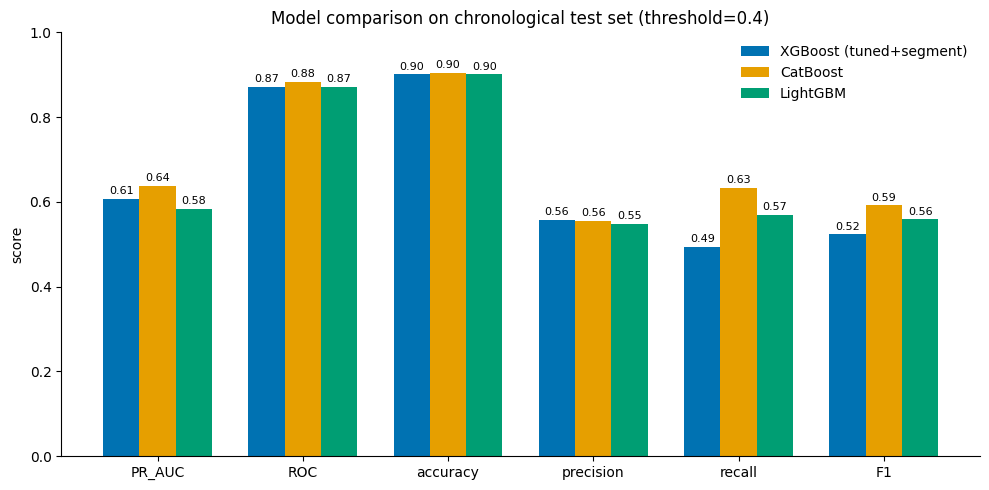

In [54]:
import matplotlib.pyplot as plt

METRICS = ["PR_AUC", "ROC", "accuracy", "precision", "recall", "F1"]
COLORS = ["#0072B2", "#E69F00", "#009E73"]  # Okabe-Ito, colorblind-safe

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METRICS))
width = 0.25
for i, (model_name, color) in enumerate(zip(comparison.index, COLORS)):
    vals = comparison.loc[model_name, METRICS].to_numpy(dtype=float)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model_name, color=color)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title(f"Model comparison on chronological test set (threshold={TH})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Is CatBoost's edge real or noise? Bootstrap the PR_AUC difference


In [55]:
rng = np.random.RandomState(0)
diffs = []
n = len(y_test)
for _ in range(2000):
    idx = rng.randint(0, n, n)
    yy = y_test[idx]
    if yy.sum() == 0 or yy.sum() == len(yy):
        continue
    diffs.append(average_precision_score(yy, p_test_cb[idx]) - average_precision_score(yy, p_test_t[idx]))
diffs = np.array(diffs)

print(f"CatBoost - XGBoost PR_AUC diff: mean {diffs.mean():+.4f}  SD {diffs.std():.4f}")
print(f"CatBoost wins in {(diffs > 0).mean():.1%} of {len(diffs)} resamples")
print(f"95% CI [{np.percentile(diffs, 2.5):+.4f}, {np.percentile(diffs, 97.5):+.4f}]")


CatBoost - XGBoost PR_AUC diff: mean +0.0302  SD 0.0162
CatBoost wins in 97.4% of 2000 resamples
95% CI [-0.0007, +0.0634]


## By segment — is CatBoost's gain broad, or coming from one segment?


In [56]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    yys = y_test[m_]
    if yys.sum() == 0 or yys.sum() == len(yys):
        rows.append({"segment": s, "n": m_.sum(), "XGBoost": np.nan, "CatBoost": np.nan})
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "XGBoost": average_precision_score(yys, p_test_t[m_]),
                "CatBoost": average_precision_score(yys, p_test_cb[m_])})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  XGBoost  CatBoost
enterprise 308   0.5965    0.5998
mid-market 170   0.6591    0.6861
       smb 109   0.6203    0.6575
  start-up  93   0.7061    0.7236
        2k  18   0.3333    0.3333
   unknown  17      NaN       NaN


## CatBoost calibration — sum_p/act = 1.17 means it over-predicts overall, check where


In [ ]:
print(rel(y_test, p_test_cb).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test_cb.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    456     0.0145  0.0219  0.0075
  5%-10%     71     0.0711  0.0423 -0.0289
 10%-20%     61     0.1400  0.1803  0.0403
 20%-40%     37     0.3006  0.1351 -0.1655
 40%-60%     36     0.4863  0.3333 -0.1530
 60%-80%     25     0.6924  0.6000 -0.0924
80%-100%     29     0.9138  0.7931 -0.1207

aggregate: predicted 0.1295 vs actual 0.1105


## Time-aware calibration for CatBoost — train / calibration / test, no leakage into the final test


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# carve a calibration slice out of what used to be pure "train": the final
# test period stays untouched, calibration only ever sees the middle slice.
train2_cut = int(len(train) * 0.65)   # ~65% train / ~15% calibration / 20% test (unchanged)
y_train2, y_cal = y[:train2_cut], y[train2_cut:cut]
Xr_train2, Xr_cal = Xraw[:train2_cut], Xraw[train2_cut:cut]
print(f"train2 {len(y_train2)}   cal {len(y_cal)}/{y_cal.sum()} won   test {len(y_test)}/{y_test.sum()} won (unchanged)")

catboost_model2 = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train2, y_train2)
p_cal_raw = catboost_model2.predict_proba(Xr_cal)[:, 1]
p_test_raw2 = catboost_model2.predict_proba(Xr_test)[:, 1]

sigmoid_cal = LogisticRegression().fit(p_cal_raw.reshape(-1, 1), y_cal)
p_test_sig = sigmoid_cal.predict_proba(p_test_raw2.reshape(-1, 1))[:, 1]

isotonic_cal = IsotonicRegression(out_of_bounds="clip").fit(p_cal_raw, y_cal)
p_test_iso = isotonic_cal.predict(p_test_raw2)

print(pd.DataFrame({
    "raw (2322 train rows)": m(y_test, p_test_raw2),
    "sigmoid-calibrated": m(y_test, p_test_sig),
    "isotonic-calibrated": m(y_test, p_test_iso),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))


train2 2322   cal 536/50 won   test 715/79 won (unchanged)
                             n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
raw (2322 train rows) 715.0000 79.0000 0.1105  0.5872 5.3143 0.8685 0.0711     1.1672
sigmoid-calibrated    715.0000 79.0000 0.1105  0.5872 5.3143 0.8685 0.0688     0.9671
isotonic-calibrated   715.0000 79.0000 0.1105  0.5535 5.0099 0.8716 0.0696     0.9908


Note: raw here uses only the 2322-row train slice (less data than the 2858-row CatBoost above), so its PR_AUC/Brier are worse than the earlier `p_test_cb` — that's the honest cost of holding out a calibration period. Sigmoid preserves ranking exactly (monotonic transform), isotonic can lose a little ranking resolution with only 536 calibration rows.


In [59]:
print("raw:")
print(rel(y_test, p_test_raw2).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nsigmoid-calibrated:")
print(rel(y_test, p_test_sig).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nisotonic-calibrated:")
print(rel(y_test, p_test_iso).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


raw:
     bin  deals  predicted  actual     err
   0%-5%    470     0.0150  0.0234  0.0084
  5%-10%     64     0.0712  0.0625 -0.0087
 10%-20%     53     0.1404  0.1321 -0.0084
 20%-40%     37     0.2859  0.3243  0.0384
 40%-60%     34     0.4774  0.3235 -0.1539
 60%-80%     25     0.6970  0.3200 -0.3770
80%-100%     32     0.9042  0.8125 -0.0917

sigmoid-calibrated:
     bin  deals  predicted  actual     err
   0%-5%    512     0.0377  0.0254 -0.0123
  5%-10%     83     0.0659  0.1325  0.0667
 10%-20%     29     0.1446  0.3448  0.2002
 20%-40%     32     0.2745  0.3125  0.0380
 40%-60%     22     0.4998  0.3636 -0.1361
 60%-80%     27     0.7206  0.7037 -0.0169
80%-100%     10     0.8183  0.8000 -0.0183

isotonic-calibrated:
     bin  deals  predicted  actual     err
   0%-5%    545     0.0112  0.0275  0.0163
  5%-10%     25     0.0714  0.1600  0.0886
 10%-20%     37     0.1606  0.2703  0.1096
 20%-40%     45     0.3452  0.2889 -0.0563
 40%-60%      1     0.4172  1.0000  0.5828
 60%-8

## Calibration by segment — is the overconfidence global, or one segment?


In [60]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    if y_test[m_].sum() == 0:
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "actual": y_test[m_].mean(),
                "raw_pred": p_test_raw2[m_].mean(),
                "calibrated_pred": p_test_sig[m_].mean()})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  actual  raw_pred  calibrated_pred
enterprise 308  0.0617    0.0652           0.0645
mid-market 170  0.1353    0.1137           0.0980
       smb 109  0.1101    0.1111           0.0953
  start-up  93  0.2581    0.4108           0.2875
        2k  18  0.0556    0.1233           0.1182


## Threshold table for the calibrated model — don't reuse the old 0.4 cutoff blindly


In [61]:
rows = []
for th in (0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test_sig >= th).astype(int)
    rows.append({"Threshold": th, "precision": precision_score(y_test, yp, zero_division=0),
                "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp),
                "Found": yp[y_test == 1].sum()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


 Threshold  precision  recall    F1  Found
     0.600      0.730   0.342 0.466     27
     0.500      0.660   0.392 0.492     31
     0.400      0.593   0.443 0.507     35
     0.300      0.588   0.506 0.544     40
     0.200      0.495   0.570 0.529     45
     0.100      0.458   0.696 0.553     55


## Give start-up its own calibrator? Testing since it's the one segment that's off


In [62]:
seg_cal = train.segment.iloc[train2_cut:cut].reset_index(drop=True).to_numpy()
su_cal, su_test = seg_cal == "start-up", seg_test.to_numpy() == "start-up"

startup_cal = LogisticRegression().fit(p_cal_raw[su_cal].reshape(-1, 1), y_cal[su_cal])
p_test_hybrid = p_test_sig.copy()
p_test_hybrid[su_test] = startup_cal.predict_proba(p_test_raw2[su_test].reshape(-1, 1))[:, 1]

print(pd.DataFrame({
    "global sigmoid": m(y_test, p_test_sig),
    "hybrid (start-up gets its own calibrator)": m(y_test, p_test_hybrid),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nstart-up only: actual {y_test[su_test].mean():.4f}   global pred {p_test_sig[su_test].mean():.4f}   hybrid pred {p_test_hybrid[su_test].mean():.4f}")


                                                 n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
global sigmoid                            715.0000 79.0000 0.1105  0.5872 5.3143 0.8685 0.0688     0.9671
hybrid (start-up gets its own calibrator) 715.0000 79.0000 0.1105  0.5735 5.1905 0.8609 0.0699     1.0484

start-up only: actual 0.2581   global pred 0.2875   hybrid pred 0.3566


**Verdict: don't split it out.** The start-up calibration slice only has 73 rows / 23 positives — a dedicated calibrator overfits on that noise and makes start-up *more* wrong (predicted 0.357 vs actual 0.258, worse than the global calibrator's 0.288), and it drags overall Brier/PR_AUC down too. Same lesson as isotonic above: with this little data, a single global sigmoid calibrator generalizes better than anything segment-specific. Keeping the global sigmoid calibrator as the final choice.


## Final summary — V0 model choice

**Model:** CatBoost, native categorical handling, chronological train(65%)/calibration(15%)/test(20%) split, no shuffling.

**What we tried and why it's (or isn't) in the final pipeline:**

| Idea | Result | In final pipeline? |
|---|---|---|
| `segment` as a plain feature | Model conditions on it, 4th-most-important feature | Yes |
| segment × feature interaction terms | No PR_AUC gain — trees already split on segment then feature, interactions add nothing a depth-4 tree doesn't already do | No |
| XGBoost hyperparameter search (RandomizedSearchCV) | No gain, didn't touch the OOF→test gap | No — defaults were fine |
| CatBoost vs XGBoost vs LightGBM | CatBoost wins on PR_AUC/ROC/Brier/recall; bootstrap 95% CI [-0.0007, +0.0634] — real edge, not huge | **CatBoost chosen** |
| Global sigmoid calibration | Brier 0.0711 → 0.0688, ranking unchanged (monotonic) | Yes |
| Isotonic calibration | Brier improved less, PR_AUC dropped (0.5872 → 0.5535) — overfits the 536-row calibration slice | No |
| Per-segment (start-up) calibrator | Made start-up *more* wrong, same small-sample overfitting problem | No |

**What's still broken, unresolved:**
- **Temporal drift is the dominant problem, not segment mixing or model choice.** OOF PR_AUC ~0.86 vs chronological test ~0.59-0.64 for every model tried. A random split closes this gap almost entirely (OOF 0.83 → test 0.82), proving it's *when* the deal happened, not *what kind* of deal. Nobody has yet looked at *what* changed over time (feature distributions / process changes by month) — that's the next real lever, not more model tuning.
- **`start-up` is the one segment CatBoost is overconfident on** (raw predicted 41% vs actual 26%); global calibration only partly corrects it (to 29%) because there isn't enough data to fix it precisely.
- **`2k` and `unknown` segments** (~140 rows combined) look like a data/mapping issue, not real segments — worth checking upstream before trusting `segment`-derived signal further.
- **Threshold 0.4** was picked before calibration; re-validated above on the calibrated probabilities and it still roughly holds (precision 0.59 / recall 0.44), but should be re-checked any time the calibrator changes.

**Production note:** as more time passes, the train/cal/test windows should roll forward — refit periodically rather than treating this as a fixed model, since drift (not staleness of features) is the main threat to accuracy.
